# Algorithmic Benchmarking

## Power Spectral Density vs. Fourier Transform of Autocorrelation Function

The Wiener-Khinchin theorem (for proof, refer to: [`docs/VDOS_Math.pdf`](docs/VDOS_Math.pdf)) states that for any stochastic process $X(t)$ that is wide-sense stationary (i.e., its mean is constant over time, and its autocorrelation depends solely on the time lag $\tau$, rather than the absolute time $t$), the Power Spectral Density (PSD) is exactly equal to the Fourier Transform of its Autocorrelation Function (ACF).

Since the Vibrational Density of States (VDOS) is defined as the mass-weighted velocity PSD (VPSD), and the VDOS is rigorously defined only for equilibrium systems—making the atomic velocities wide-sense stationary stochastic processes—the Wiener-Khinchin theorem gives the VDOS definition "two sides":

1. The direct **VPSD** formulation.
2. The Fourier transform of the **Velocity Autocorrelation Function (VACF)**.

Even though these represent two sides of the same mathematical coin, one approach is significantly cheaper to compute. Estimating the VPSD directly via Fast Fourier Transform algorithms scales as $\mathcal{O}(N \log N)$, whereas explicitly calculating the time-domain VACF scales quadratically as $\mathcal{O}(N^2)$. 

This notebook will demonstrate this computational divergence by benchmarking both approaches on simple systems. It will also compare the various methods available for discretely estimating the PSD, evaluating their trade-offs between execution speed, variance, and spectral resolution.

## Generating a Synthetic Velocity Trajectory

To rigorously evaluate these algorithms, a synthetic signal made of deterministic harmonic oscillations and stochastic thermal noise. By applying the various estimators to this noisy synthetic signal, it's easy to visualize how each method highlights the deterministic instrinsic harmonic modes.

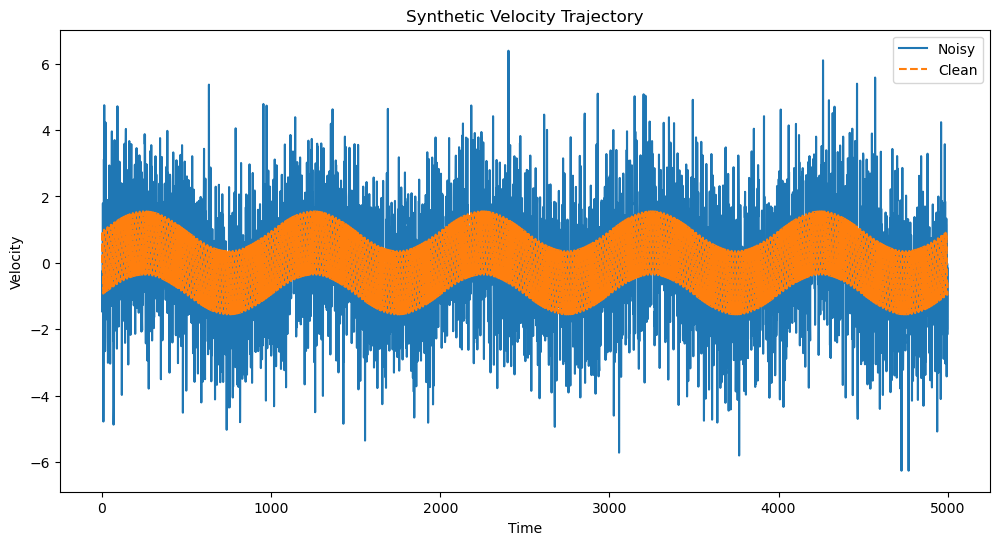

In [78]:
import numpy as np
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import periodogram, welch
from scipy.fft import rfft, rfftfreq
from scipy.integrate import simpson
import time

def generate_synthetic_trajectory(f_1: Optional[float]=float(0.1), f_2: Optional[float]=float(0.001), n_frames: Optional[int]=5000, dt: Optional[np.double]=np.double(1.0), noise_level: Optional[float]=float(1.5)) -> tuple:
    """
    Generates a synthetic velocity trajectory mimicking molecular vibrations.
    """
    # Create the time axis
    time = np.arange(n_frames) * dt
    
    # Build the signal
    velocity = 1.0 * np.sin(2 * np.pi * f_1 * time)
    velocity += 0.6 * np.sin(2 * np.pi * f_2 * time)
    
    # Add Gaussian "thermal" noise
    clean_velocity = velocity.copy()
    velocity += np.random.normal(loc=0.0, scale=noise_level, size=n_frames)
    
    return time, velocity, clean_velocity

# Generate the data for the rest of the notebook
f_1=0.1
f_2=0.001
t, v_mock, v_clean = generate_synthetic_trajectory(f_1=f_1, f_2=f_2)

# Plot the synthetic trajectory
plt.figure(figsize=(12, 6))
plt.plot(t, v_mock, label="Noisy")
plt.plot(t, v_clean, label="Clean", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Synthetic Velocity Trajectory")
plt.legend()
plt.show()

## Implementing Spectral Estimators

To compare  we define seven distinct PSD estimators. 

Methods 1 through 6 utilize the **PSD route** ($\mathcal{O}(N \log N)$). By modulating the segmentation (`nperseg`), overlap (`noverlap`), and tapering function (`window`), these algorithms span from the raw, high-variance Periodogram to the heavily smoothed, statistically consistent Welch's method. Method 7 represents the **VACF approach**, computing the discrete time-lagged Velocity Autocorrelation Function (VACF) via an explicit $\mathcal{O}(N^2)$ summation prior to transforming into the frequency domain.

To facilitate comparison between the methods, **every estimator below is explicitly normalized** so that $\int S(f) df = 1$.

In [79]:
def psd_raw_no_window(v: np.ndarray, dt: float) -> tuple:
    """1. Raw Periodogram (No Window)"""
    fs = 1.0 / dt
    freqs = rfftfreq(len(v), d=dt)
    psd = (1/ len(v)) * np.abs(rfft(v))**2
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_raw_with_window(v: np.ndarray, dt: float) -> tuple:
    """2. Modified Periodogram (With Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = periodogram(v, fs=fs, window='hann', scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_bartlett_no_window(v: np.ndarray, dt: float, nperseg: int) -> tuple:
    """3. Bartlett's Method (No overlapping, No Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='boxcar', nperseg=nperseg, noverlap=0, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_bartlett_with_window(v: np.ndarray, dt: float, nperseg: int) -> tuple:
    """4. Bartlett's Method with Window (No overlapping, Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='hann', nperseg=nperseg, noverlap=0, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_welch_no_window(v: np.ndarray, dt: float, nperseg: int) -> tuple:
    """5. Welch's Method without Window (50% Overlap, Boxcar/No Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='boxcar', nperseg=nperseg, noverlap=nperseg//2, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def psd_welch_with_window(v: np.ndarray, dt: float, nperseg: int) -> tuple:
    """6. True Welch's Method (50% Overlap, Hann Window)"""
    fs = 1.0 / dt
    freqs, psd = welch(v, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg//2, scaling='density')
    # Normalize area to 1.0
    psd_normalized = psd / simpson(psd, x=freqs)
    return freqs, psd_normalized

def explicit_vacf(v: np.ndarray, max_lag: int) -> np.ndarray:
    """Computes the explicit time-domain VACF."""
    N = len(v)
    vacf = np.zeros(max_lag)
    for lag in range(max_lag):
        vacf[lag] = np.mean(v[:N-lag] * v[lag:])
        
    if vacf[0] != 0:
        vacf = vacf / vacf[0]
    return vacf

def fft_explicit_vacf(v: np.ndarray, dt: float, max_lag: int) -> tuple:
    """7. PSD via FFT of the explicitly computed VACF"""
    # compute VACF
    vacf = explicit_vacf(v, max_lag)
    
    # compute FFT of VACF
    vacf_fft = rfft(vacf)
    
    # 4. Generate the corresponding frequency bins
    fs = 1.0 / dt
    freqs = rfftfreq(max_lag, d=dt)
    
    # 5. Normalize area to 1.0
    vacf_fft_normalized = vacf_fft / simpson(vacf_fft, x=freqs)
    
    return freqs, vacf_fft_normalized

## Visualizing Wiener-Khinchin and Bias-Variance Tradeoff

With the synthetic trajectory generated and the estimators defined, it's easy to apply all seven methods to the noisy data (`v_mock`) and visualize their outputs simultaneously. 

To make the comparison clear, the plot below heavily weights the visual prominence of the algorithms. The estimators are layered to highlight the **bias-variance tradeoff**:

* **(1)** Raw periodograms use the entire timeseries, so they maximize the spectral resolution (which is inversely related to the signal length); however, they are inconsistent estimators of the PSD (that's why it's necessary to compute the expected value).
* **(2)** For a given signal, to get the expected value, methods like Bartlett's method or Welch's method split the signal into smaller segments before computing the periodogram; however, since the smaller segments have a smaller length, the spectral resolution is necessarily lower. 

The visualization below clearly demonstrates why the expected value in the PSD definition is necessary for random processes: the **variance of a stochastic process does not vanish** as the length of the timeseries tends to infinity. As a result, the intensity of the peak for the raw periodogram is not accurate. On the other hand, the averaging methods have a **lower spectral resolution**, so the peaks have a higher variance and a **lower intensity** (since the peaks are essentially smeared).

The best solution would be to ensemble average, that way the expected value of the periodograms is a better estimator of the PSD, but at the same time the spectral resolution is not compromised.

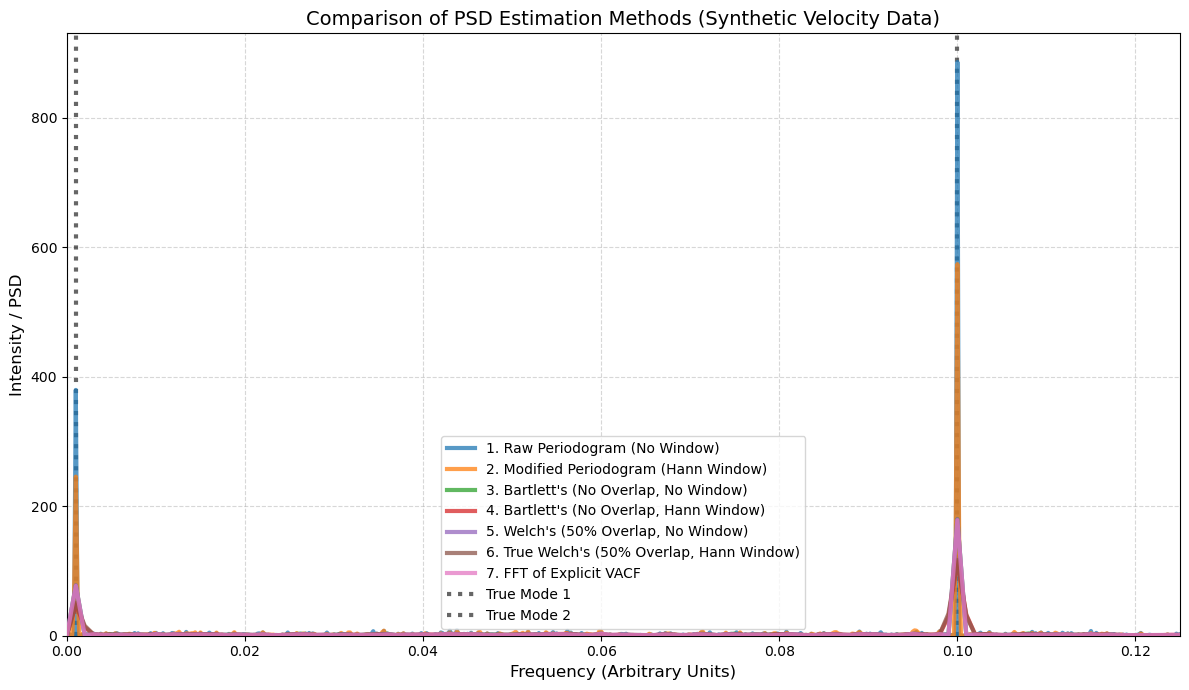

In [80]:
dt = 1.0
nperseg = 1000  
max_lag = 1000  

psd_methods = {
    "1. Raw Periodogram (No Window)": lambda v: psd_raw_no_window(v, dt),
    "2. Modified Periodogram (Hann Window)": lambda v: psd_raw_with_window(v, dt),
    "3. Bartlett's (No Overlap, No Window)": lambda v: psd_bartlett_no_window(v, dt, nperseg),
    "4. Bartlett's (No Overlap, Hann Window)": lambda v: psd_bartlett_with_window(v, dt, nperseg),
    "5. Welch's (50% Overlap, No Window)": lambda v: psd_welch_no_window(v, dt, nperseg),
    "6. True Welch's (50% Overlap, Hann Window)": lambda v: psd_welch_with_window(v, dt, nperseg),
    "7. FFT of Explicit VACF": lambda v: fft_explicit_vacf(v, dt, max_lag)
}

plt.figure(figsize=(12, 7))

colors = [cm.tab10(i) for i in range(len(psd_methods))]

for i, (title, func) in enumerate(psd_methods.items()):
    freqs, psd = func(v_mock)
    color = colors[i]
    plt.plot(freqs, psd, label=title, color=color, alpha=0.75, linewidth=3.0, zorder=z)

# --- Ground Truth Markers ---
plt.axvline(x=f_1, color='black', linestyle=':', alpha=0.6, label='True Mode 1', linewidth=3.0)
plt.axvline(x=f_2, color='black', linestyle=':', alpha=0.6, label='True Mode 2', linewidth=3.0)

plt.xlim(0, 0.3)
plt.ylim(0, None) # Starts at zero for better comparison of noise floors
plt.title("Comparison of PSD Estimation Methods (Synthetic Velocity Data)", fontsize=14)
plt.xlabel("Frequency (Arbitrary Units)", fontsize=12)
plt.ylabel("Intensity / PSD", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.xlim(0,0.125)
plt.tight_layout()
plt.show()

## Computational Complexity: $\mathcal{O}(N \log N)$ vs. $\mathcal{O}(N^2)$

As mentioned before, the VPSD approach scales as $\mathcal{O}(N \log N)$, meanwhile the VACF scales as $\mathcal{O}(N^2)$. The following visualization analyzes the time it takes for each of the methods to process time series of varions lengths (10,100,1000,10000,100000).

N          | Status
------------------------------
10         | Completed all methods
100        | Completed all methods
1000       | Completed all methods
10000      | Completed all methods
100000     | Completed all methods


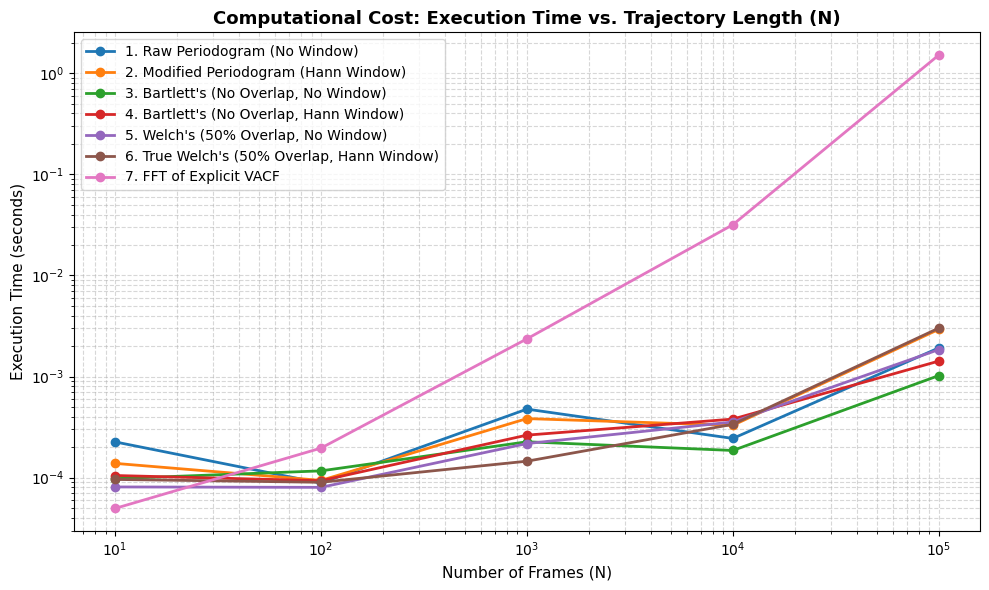

In [83]:
N_values = [10,100,1000,10000,100000]
dt = 1.0

results = {
    "1. Raw Periodogram (No Window)": [],
    "2. Modified Periodogram (Hann Window)": [],
    "3. Bartlett's (No Overlap, No Window)": [],
    "4. Bartlett's (No Overlap, Hann Window)": [],
    "5. Welch's (50% Overlap, No Window)": [],
    "6. True Welch's (50% Overlap, Hann Window)": [],
    "7. FFT of Explicit VACF": []
}

print(f"{'N':<10} | Status")
print("-" * 30)

for N in N_values:
    sim_data = generate_synthetic_trajectory(n_frames=N, dt=dt)
    v_test = sim_data[1] 
    
    nperseg_val = N // 4
    max_lag_val = N // 4

    # --- Method 1 ---
    t0 = time.perf_counter()
    periodogram(v_test, fs=1/dt, window='boxcar')
    results["1. Raw Periodogram (No Window)"].append(time.perf_counter() - t0)
    
    # --- Method 2 ---
    t0 = time.perf_counter()
    periodogram(v_test, fs=1/dt, window='hann')
    results["2. Modified Periodogram (Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Method 3 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='boxcar', nperseg=nperseg_val, noverlap=0)
    results["3. Bartlett's (No Overlap, No Window)"].append(time.perf_counter() - t0)
    
    # --- Method 4 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='hann', nperseg=nperseg_val, noverlap=0)
    results["4. Bartlett's (No Overlap, Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Method 5 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='boxcar', nperseg=nperseg_val, noverlap=nperseg_val//2)
    results["5. Welch's (50% Overlap, No Window)"].append(time.perf_counter() - t0)
    
    # --- Method 6 ---
    t0 = time.perf_counter()
    welch(v_test, fs=1/dt, window='hann', nperseg=nperseg_val, noverlap=nperseg_val//2)
    results["6. True Welch's (50% Overlap, Hann Window)"].append(time.perf_counter() - t0)
    
    # --- Method 7 ---
    t0 = time.perf_counter()
    fft_explicit_vacf(v_test, dt, max_lag_val)
    results["7. FFT of Explicit VACF"].append(time.perf_counter() - t0)
    
    print(f"{N:<10} | Completed all methods")

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))

for name, timings in results.items():
    plt.loglog(N_values, timings, marker='o', lw=2, label=name)

plt.title("Computational Cost: Execution Time vs. Trajectory Length (N)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Frames (N)", fontsize=11)
plt.ylabel("Execution Time (seconds)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()